# Machine Learning & AI

![Colegio Bourbaki](./Images/Bourbaki.png)

## Introduccion a POMDP

Un proceso de Markov es un modelo matemático para sistemas que cambian de estado en el tiempo y donde el futuro depende solo del estado actual, no de toda la historia previa.

![MDP](./Images/markov.png)

La propiedad central se llama propiedad de Markov:
$P(S_{t+1} | S_t, S_{t-1}, ..., S_0) = P(S_{t+1} | S_t)$

**Intuición:**
si conozco bien el estado presente, el pasado ya no aporta información extra para predecir el siguiente estado.

**Ejemplo simple:**
si un robot está en una celda de una grilla, la probabilidad de su próxima posición depende de dónde está ahora y de la acción que tome, no de todas las celdas por las que pasó antes.

En aprendizaje por refuerzo, esta idea es clave porque un MDP asume justamente que el estado actual resume toda la información necesaria para decidir.

![MDP](./Images/rl.jpg)


Un POMDP (Partially Observable Markov Decision Process) aparece cuando el agente no observa el estado real $s_t$, sino una observacion parcial $o_t$.

En un MDP el estado observado alcanza para decidir. En un POMDP hace falta al menos una de estas tres ideas:
- memoria,
- historial de acciones y observaciones,
- o un belief state $b_t = P(s_t | o_{1:t}, a_{1:t-1})$.

## De MDP a POMDP
- MDP: $(S, A, T, R)$
- POMDP: $(S, A, T, R, O, Z)$

![POMDP](./Images/pomdp.png)

Aparecen dos objetos nuevos:
- $O$: conjunto de observaciones posibles.
- $Z(o | s', a)$: modelo de observacion.

La diferencia conceptual importante es que la politica ya no deberia depender solo del estado visible, porque ese estado visible puede ser ambiguo.

El belief state es directamente una idea bayesiana. En un POMDP, como no observamos el estado real $s_t$, mantenemos una distribución de probabilidad sobre los estados posibles:

$b_t(s) = P(s_t = s | o_{1:t}, a_{1:t-1})$

Eso es exactamente una creencia bayesiana: una probabilidad posterior sobre el estado oculto dado el historial de observaciones y acciones.

Se actualiza en dos pasos:

**Predicción:** usamos el modelo de transición para estimar a qué estados podrías haber pasado.

**Corrección:** usamos nueva observación para reponderar esas probabilidades con Bayes.

En forma conceptual:

$belief nuevo ∝ likelihood × belief predicho$

O sea:
belief predicho: lo que esperabamos antes de observar

likelihood: qué tan compatible es la observación con cada estado

resultado: posterior

Por eso el belief state es una representación bayesiana del estado oculto.

![MDP](./Images/mdps.png)

## Librerias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

### Configuraciones

In [2]:
np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.figsize"] = (8, 4.5)

In [3]:
CorridorObservation = str
GridState = Tuple[int, int]
SensorObservation = Tuple[int, int, int, int]

## Entornos base

### Corredor

In [4]:
@dataclass
class CorridorPOMDP:
    """Small deterministic corridor with aliased observations."""

    length: int = 5
    start_state: int = 2
    goal_state: int | None = None
    step_cost: float = -0.01
    state: int = field(init=False)

    def __post_init__(self) -> None:
        if self.length < 3:
            raise ValueError("length must be at least 3")
        if self.goal_state is None:
            self.goal_state = self.length - 1
        self.state = self.start_state

    def states(self) -> List[int]:
        return list(range(self.length))

    def reset(self, state: int | None = None) -> Tuple[int, CorridorObservation]:
        self.state = self.start_state if state is None else state
        return self.state, self.observe(self.state)

    def observe(self, state: int | None = None) -> CorridorObservation:
        position = self.state if state is None else state
        if position == 0:
            return "left_wall"
        if position == self.length - 1:
            return "right_wall"
        return "hallway"

    def transition(self, state: int, action: str) -> int:
        if action not in {"left", "right", "stay"}:
            raise ValueError(f"unknown action: {action}")
        delta = {"left": -1, "right": 1, "stay": 0}[action]
        return min(max(state + delta, 0), self.length - 1)

    def step(self, action: str) -> Tuple[int, CorridorObservation, float, bool]:
        self.state = self.transition(self.state, action)
        done = self.state == self.goal_state
        reward = 1.0 if done else self.step_cost
        return self.state, self.observe(self.state), reward, done

    def alias_map(self) -> Dict[CorridorObservation, List[int]]:
        mapping: Dict[CorridorObservation, List[int]] = defaultdict(list)
        for state in self.states():
            mapping[self.observe(state)].append(state)
        return dict(mapping)

    def update_belief(
        self,
        belief: np.ndarray,
        action: str,
        observation: CorridorObservation,
    ) -> np.ndarray:
        belief = np.asarray(belief, dtype=float)
        if belief.shape != (self.length,):
            raise ValueError(f"belief must have shape ({self.length},)")

        predicted = np.zeros(self.length, dtype=float)
        for state, prob in enumerate(belief):
            if prob == 0:
                continue
            next_state = self.transition(state, action)
            predicted[next_state] += prob

        likelihood = np.array(
            [
                1.0 if self.observe(state) == observation else 0.0
                for state in self.states()
            ],
            dtype=float,
        )
        posterior = predicted * likelihood
        total = posterior.sum()
        if total == 0:
            raise ValueError("inconsistent belief / action / observation tuple")
        return posterior / total

### Tigre

In [5]:
@dataclass
class TigerPOMDP:
    """Classic tiger problem with noisy listening."""

    listen_accuracy: float = 0.85
    safe_reward: float = 10.0
    tiger_reward: float = -100.0
    listen_cost: float = -1.0
    seed: int = 7
    rng: np.random.Generator = field(init=False, repr=False)
    tiger_left: bool = field(init=False)

    def __post_init__(self) -> None:
        self.rng = np.random.default_rng(self.seed)
        self.reset()

    def reset(self, tiger_left: bool | None = None) -> str:
        if tiger_left is None:
            tiger_left = bool(self.rng.integers(0, 2))
        self.tiger_left = tiger_left
        return self.hidden_state()

    def hidden_state(self) -> str:
        return "tiger_left" if self.tiger_left else "tiger_right"

    def listen(self) -> str:
        correct_observation = "hear_left" if self.tiger_left else "hear_right"
        wrong_observation = "hear_right" if self.tiger_left else "hear_left"
        if self.rng.random() < self.listen_accuracy:
            return correct_observation
        return wrong_observation

    def open(self, door: str) -> float:
        if door not in {"left", "right"}:
            raise ValueError(f"unknown door: {door}")
        safe = (door == "left" and not self.tiger_left) or (
            door == "right" and self.tiger_left
        )
        return self.safe_reward if safe else self.tiger_reward

In [6]:
def tiger_bayes_update(
    pr_tiger_left: float,
    observation: str,
    listen_accuracy: float = 0.85,
) -> float:
    if not 0.5 <= listen_accuracy < 1.0:
        raise ValueError("listen_accuracy must be in [0.5, 1.0)")
    if observation not in {"hear_left", "hear_right"}:
        raise ValueError(f"unknown observation: {observation}")

    if observation == "hear_left":
        likelihood_if_left = listen_accuracy
        likelihood_if_right = 1.0 - listen_accuracy
    else:
        likelihood_if_left = 1.0 - listen_accuracy
        likelihood_if_right = listen_accuracy

    numerator = likelihood_if_left * pr_tiger_left
    denominator = numerator + likelihood_if_right * (1.0 - pr_tiger_left)
    return numerator / denominator


def tiger_expected_values(
    pr_tiger_left: float | np.ndarray,
    safe_reward: float = 10.0,
    tiger_reward: float = -100.0,
    listen_cost: float = -1.0,
) -> Dict[str, np.ndarray]:
    probability = np.asarray(pr_tiger_left, dtype=float)
    return {
        "open_left": probability * tiger_reward + (1.0 - probability) * safe_reward,
        "open_right": probability * safe_reward + (1.0 - probability) * tiger_reward,
        "listen": np.zeros_like(probability) + listen_cost,
    }

### Grid World

In [7]:
@dataclass
class SensorGridWorld:
    """GridWorld where the agent only observes local wall sensors."""

    rows: int = 3
    cols: int = 4
    start: GridState = (2, 0)
    win_state: GridState = (0, 3)
    lose_state: GridState = (1, 3)
    blocked: GridState = (1, 1)
    step_cost: float = -0.04
    state: GridState = field(init=False)

    def __post_init__(self) -> None:
        self.state = self.start

    def legal_states(self) -> List[GridState]:
        states: List[GridState] = []
        for row in range(self.rows):
            for col in range(self.cols):
                state = (row, col)
                if state != self.blocked:
                    states.append(state)
        return states

    def reset(self, state: GridState | None = None) -> Tuple[GridState, SensorObservation]:
        self.state = self.start if state is None else state
        return self.state, self.observe(self.state)

    def is_terminal(self, state: GridState | None = None) -> bool:
        current = self.state if state is None else state
        return current in {self.win_state, self.lose_state}

    def _valid(self, state: GridState) -> bool:
        row, col = state
        return (
            0 <= row < self.rows
            and 0 <= col < self.cols
            and state != self.blocked
        )

    def transition(self, state: GridState, action: str) -> GridState:
        if action not in {"up", "down", "left", "right"}:
            raise ValueError(f"unknown action: {action}")
        if self.is_terminal(state):
            return state

        delta = {
            "up": (-1, 0),
            "down": (1, 0),
            "left": (0, -1),
            "right": (0, 1),
        }[action]
        candidate = (state[0] + delta[0], state[1] + delta[1])
        return candidate if self._valid(candidate) else state

    def observe(self, state: GridState | None = None) -> SensorObservation:
        row, col = self.state if state is None else state
        up_wall = 0 if self._valid((row - 1, col)) else 1
        down_wall = 0 if self._valid((row + 1, col)) else 1
        left_wall = 0 if self._valid((row, col - 1)) else 1
        right_wall = 0 if self._valid((row, col + 1)) else 1
        return (up_wall, down_wall, left_wall, right_wall)

    def reward(self, state: GridState | None = None) -> float:
        current = self.state if state is None else state
        if current == self.win_state:
            return 1.0
        if current == self.lose_state:
            return -1.0
        return self.step_cost

    def step(self, action: str) -> Tuple[GridState, SensorObservation, float, bool]:
        self.state = self.transition(self.state, action)
        done = self.is_terminal(self.state)
        return self.state, self.observe(self.state), self.reward(self.state), done

    def alias_map(self) -> Dict[SensorObservation, List[GridState]]:
        mapping: Dict[SensorObservation, List[GridState]] = defaultdict(list)
        for state in self.legal_states():
            mapping[self.observe(state)].append(state)
        return dict(mapping)

    def rollout(
        self,
        actions: List[str],
        start_state: GridState | None = None,
    ) -> List[Dict[str, object]]:
        state, observation = self.reset(start_state)
        history: List[Dict[str, object]] = [
            {
                "step": 0,
                "action": "reset",
                "state": state,
                "observation": observation,
                "reward": 0.0,
                "done": self.is_terminal(state),
            }
        ]

        for step_index, action in enumerate(actions, start=1):
            state, observation, reward, done = self.step(action)
            history.append(
                {
                    "step": step_index,
                    "action": action,
                    "state": state,
                    "observation": observation,
                    "reward": reward,
                    "done": done,
                }
            )
            if done:
                break
        return history


In [8]:
def format_sensor_observation(observation: SensorObservation) -> str:
    names = ("U", "D", "L", "R")
    return " ".join(f"{name}:{value}" for name, value in zip(names, observation))

### Ejemplo 1: corredor con observaciones con alias
El agente se mueve en un corredor 1D. En el medio siempre observa `hallway`, asi que varios estados ocultos se ven iguales.

Eso ya rompe la hipotesis de MDP observable: la observacion actual no alcanza para saber donde esta.


In [9]:
corridor = CorridorPOMDP(length=5, start_state=2, goal_state=4)

print("Observaciones posibles y estados ocultos compatibles:")
for observation, states in corridor.alias_map().items():
    print(f"  {observation:>10} -> {states}")


Observaciones posibles y estados ocultos compatibles:
   left_wall -> [0]
     hallway -> [1, 2, 3]
  right_wall -> [4]


In [10]:
corridor.reset(state=2)

belief = np.ones(corridor.length) / corridor.length
belief = corridor.update_belief(belief, action="stay", observation=corridor.observe())

print("Belief despues de observar solo 'hallway':", belief)

for action in ["right", "right"]:
    _, observation, reward, done = corridor.step(action)
    belief = corridor.update_belief(belief, action=action, observation=observation)
    print(
        f"accion={action:>5} | observacion={observation:>10} | "
        f"belief={np.round(belief, 3)} | reward={reward:.2f} | done={done}"
    )


Belief despues de observar solo 'hallway': [0.    0.333 0.333 0.333 0.   ]
accion=right | observacion=   hallway | belief=[0.  0.  0.5 0.5 0. ] | reward=-0.01 | done=False
accion=right | observacion=right_wall | belief=[0. 0. 0. 0. 1.] | reward=1.00 | done=True


In [11]:
def plot_corridor_belief_evolution(actions, start_state=2, length=5):
    env = CorridorPOMDP(length=length, start_state=start_state, goal_state=length - 1)
    env.reset(state=start_state)

    belief = np.ones(env.length) / env.length
    belief = env.update_belief(belief, action="stay", observation=env.observe())

    beliefs = [belief.copy()]
    true_states = [env.state]
    observations = [env.observe()]
    action_history = ["stay"]

    for action in actions:
        _, obs, reward, done = env.step(action)
        belief = env.update_belief(belief, action=action, observation=obs)

        beliefs.append(belief.copy())
        true_states.append(env.state)
        observations.append(obs)
        action_history.append(action)

        if done:
            break

    belief_matrix = np.vstack(beliefs)

    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(belief_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=1)

    for t, s in enumerate(true_states):
        ax.scatter(s, t, color="crimson", s=90, marker="*", edgecolors="black")

    ax.set_xticks(range(env.length))
    ax.set_xlabel("Estado oculto")
    ax.set_ylabel("Tiempo")
    ax.set_yticks(range(len(action_history)))
    ax.set_yticklabels([f"t={i}" for i in range(len(action_history))])
    ax.set_title("Evolucion del belief state en el corredor")
    plt.colorbar(im, ax=ax, label="Probabilidad")
    plt.tight_layout()
    plt.show()

    print("Resumen:")
    for t, (a, o, s, b) in enumerate(
        zip(action_history, observations, true_states, beliefs)
    ):
        print(
            f"t={t} | action={a:>5} | obs={o:>10} | "
            f"estado_real={s} | belief={np.round(b, 3)}"
        )

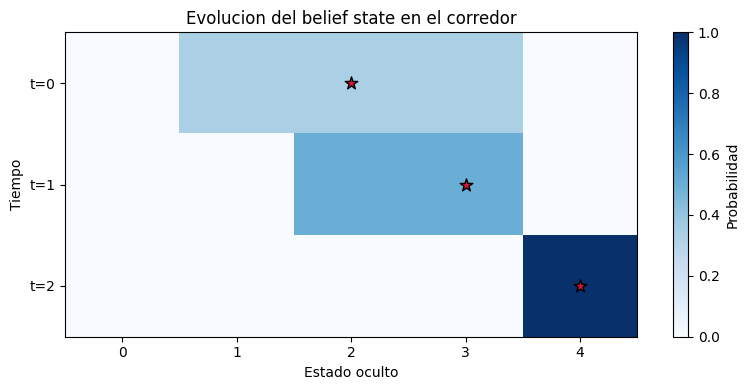

Resumen:
t=0 | action= stay | obs=   hallway | estado_real=2 | belief=[0.    0.333 0.333 0.333 0.   ]
t=1 | action=right | obs=   hallway | estado_real=3 | belief=[0.  0.  0.5 0.5 0. ]
t=2 | action=right | obs=right_wall | estado_real=4 | belief=[0. 0. 0. 0. 1.]


In [12]:
# Celda 2: corredor con heatmap de belief
plot_corridor_belief_evolution(actions=["right", "right"], start_state=2, length=5)

### Ejemplo 2: Tiger problem
Detras de una puerta hay un tigre y detras de la otra hay una recompensa. El agente puede abrir una puerta o escuchar.

Escuchar cuesta poco, pero devuelve una observacion ruidosa. Este es el ejemplo clasico para introducir actualizacion bayesiana en POMDP.


![Tiger Bayes Update](./Images/tiger.jpg)

In [13]:
probabilities = np.linspace(0.0, 1.0, 200)
values = tiger_expected_values(probabilities)

In [14]:
tiger = TigerPOMDP(listen_accuracy=0.85, seed=7)
hidden_state = tiger.reset(tiger_left=True)
belief = 0.5

In [15]:
print("Estado oculto usado en la demo:", hidden_state)
for step in range(1, 4):
    observation = tiger.listen()
    belief = tiger_bayes_update(belief, observation, tiger.listen_accuracy)
    values = {
        action: float(np.asarray(value))
        for action, value in tiger_expected_values(belief).items()
    }
    best_action = max(values, key=values.get)
    print(
        f"escucha {step}: {observation:>10} | "
        f"P(tiger left)={belief:.3f} | "
        f"mejor accion={best_action} | valores={values}"
    )


Estado oculto usado en la demo: tiger_left
escucha 1: hear_right | P(tiger left)=0.150 | mejor accion=listen | valores={'open_left': -6.500000000000002, 'open_right': -83.5, 'listen': -1.0}
escucha 2:  hear_left | P(tiger left)=0.500 | mejor accion=listen | valores={'open_left': -45.0, 'open_right': -45.0, 'listen': -1.0}
escucha 3:  hear_left | P(tiger left)=0.850 | mejor accion=listen | valores={'open_left': -83.5, 'open_right': -6.500000000000002, 'listen': -1.0}


In [16]:
def plot_tiger_belief_and_values(
    n_listens=6, tiger_left=True, seed=7, listen_accuracy=0.85
):
    env = TigerPOMDP(listen_accuracy=listen_accuracy, seed=seed)
    env.reset(tiger_left=tiger_left)

    beliefs = [0.5]
    observations = ["prior"]

    belief = 0.5
    for _ in range(n_listens):
        obs = env.listen()
        belief = tiger_bayes_update(belief, obs, env.listen_accuracy)
        observations.append(obs)
        beliefs.append(belief)

    xs = np.arange(len(beliefs))
    probs = np.linspace(0.0, 1.0, 300)
    values = tiger_expected_values(probs)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(xs, beliefs, marker="o", linewidth=2, color="tab:blue")
    axes[0].axhline(0.5, linestyle="--", color="gray", alpha=0.7)
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].set_xticks(xs)
    axes[0].set_xlabel("Numero de escuchas")
    axes[0].set_ylabel("P(tiger left)")
    axes[0].set_title("Posterior bayesiano en Tiger")

    for i in range(1, len(beliefs)):
        axes[0].annotate(
            observations[i].replace("hear_", ""),
            (xs[i], beliefs[i]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

    for action, series in values.items():
        axes[1].plot(probs, series, label=action, linewidth=2)

    for b in beliefs[1:]:
        axes[1].axvline(b, color="black", alpha=0.12)

    axes[1].axhline(0.0, linestyle="--", color="gray", alpha=0.7)
    axes[1].set_xlabel("P(tiger left)")
    axes[1].set_ylabel("Valor esperado")
    axes[1].set_title("Valor esperado segun la creencia")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("Resumen:")
    for i, b in enumerate(beliefs[1:], start=1):
        current_values = {
            action: float(np.asarray(value))
            for action, value in tiger_expected_values(b).items()
        }
        best_action = max(current_values, key=current_values.get)
        print(
            f"escucha={i} | obs={observations[i]:>10} | "
            f"P(tiger left)={b:.3f} | mejor_accion={best_action} | valores={current_values}"
        )

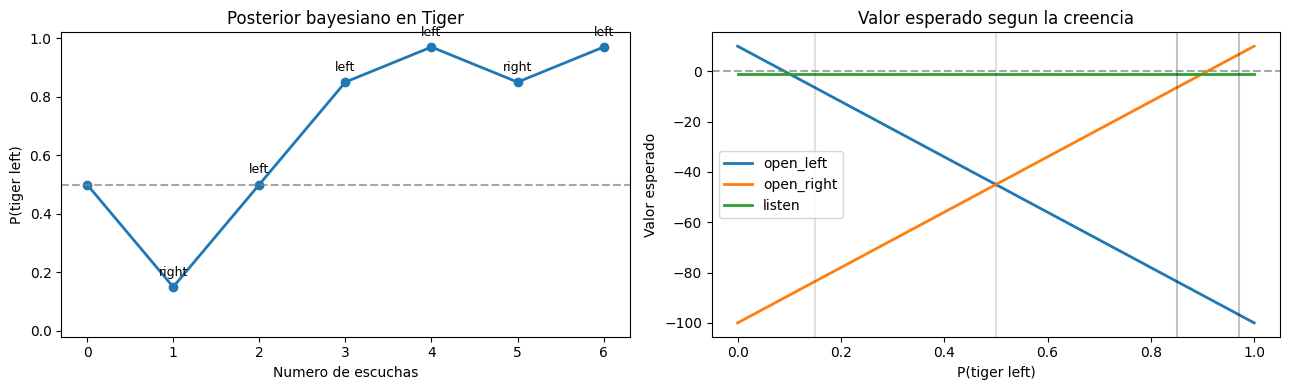

Resumen:
escucha=1 | obs=hear_right | P(tiger left)=0.150 | mejor_accion=listen | valores={'open_left': -6.500000000000002, 'open_right': -83.5, 'listen': -1.0}
escucha=2 | obs= hear_left | P(tiger left)=0.500 | mejor_accion=listen | valores={'open_left': -45.0, 'open_right': -45.0, 'listen': -1.0}
escucha=3 | obs= hear_left | P(tiger left)=0.850 | mejor_accion=listen | valores={'open_left': -83.5, 'open_right': -6.500000000000002, 'listen': -1.0}
escucha=4 | obs= hear_left | P(tiger left)=0.970 | mejor_accion=open_right | valores={'open_left': -96.6778523489933, 'open_right': 6.677852348993287, 'listen': -1.0}
escucha=5 | obs=hear_right | P(tiger left)=0.850 | mejor_accion=listen | valores={'open_left': -83.5, 'open_right': -6.500000000000002, 'listen': -1.0}
escucha=6 | obs= hear_left | P(tiger left)=0.970 | mejor_accion=open_right | valores={'open_left': -96.6778523489933, 'open_right': 6.677852348993287, 'listen': -1.0}


In [17]:
# Celda 3: Tiger con posterior + valor esperado
plot_tiger_belief_and_values(n_listens=6, tiger_left=True, seed=7, listen_accuracy=0.85)

### Ejemplo 3: GridWorld con sensores locales
El estado real sigue siendo $(fila, columna)$, pero la observacion es solo un vector de sensores de pared $(up, down, left, right)$.

El agente ya no sabe en que celda esta, solo sabe que paredes tiene alrededor.

![Board](./Images/board.png)

In [18]:
grid = SensorGridWorld()
ambiguous_observations = {
    observation: states
    for observation, states in grid.alias_map().items()
    if len(states) > 1
}

print("Observaciones ambiguas en el GridWorld con sensores de pared:")
for observation, states in ambiguous_observations.items():
    print(f"  {format_sensor_observation(observation)} -> {states}")


Observaciones ambiguas en el GridWorld con sensores de pared:
  U:1 D:1 L:0 R:0 -> [(0, 1), (2, 1)]


In [19]:
trajectory = grid.rollout(["up", "up", "right", "right", "right"])

for row in trajectory:
    print(
        f"step={row['step']} | action={row['action']:>5} | "
        f"hidden_state={row['state']} | "
        f"observation={format_sensor_observation(row['observation'])} | "
        f"reward={row['reward']:.2f} | done={row['done']}"
    )


step=0 | action=reset | hidden_state=(2, 0) | observation=U:0 D:1 L:1 R:0 | reward=0.00 | done=False
step=1 | action=   up | hidden_state=(1, 0) | observation=U:0 D:0 L:1 R:1 | reward=-0.04 | done=False
step=2 | action=   up | hidden_state=(0, 0) | observation=U:1 D:0 L:1 R:0 | reward=-0.04 | done=False
step=3 | action=right | hidden_state=(0, 1) | observation=U:1 D:1 L:0 R:0 | reward=-0.04 | done=False
step=4 | action=right | hidden_state=(0, 2) | observation=U:1 D:0 L:0 R:0 | reward=-0.04 | done=False
step=5 | action=right | hidden_state=(0, 3) | observation=U:1 D:0 L:0 R:1 | reward=1.00 | done=True


In [20]:
def plot_sensor_alias_grid(actions=None):
    env = SensorGridWorld()
    alias_map = env.alias_map()
    alias_keys = list(alias_map.keys())
    alias_id = {obs: i for i, obs in enumerate(alias_keys)}
    alias_name = {obs: chr(65 + i) for i, obs in enumerate(alias_keys)}

    grid = np.full((env.rows, env.cols), np.nan)
    for r in range(env.rows):
        for c in range(env.cols):
            state = (r, c)
            if state == env.blocked:
                continue
            obs = env.observe(state)
            grid[r, c] = alias_id[obs]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    cmap = plt.get_cmap("Set3", max(len(alias_keys), 1))
    ax.imshow(
        np.ma.masked_invalid(grid), cmap=cmap, vmin=0, vmax=max(len(alias_keys) - 1, 0)
    )

    ax.add_patch(
        plt.Rectangle(
            (env.blocked[1] - 0.5, env.blocked[0] - 0.5),
            1,
            1,
            color="black",
        )
    )

    for r in range(env.rows):
        for c in range(env.cols):
            state = (r, c)
            if state == env.blocked:
                ax.text(
                    c,
                    r,
                    "X",
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=14,
                    fontweight="bold",
                )
                continue

            obs = env.observe(state)
            label = alias_name[obs]

            extra = ""
            if state == env.start:
                extra = "\nSTART"
            elif state == env.win_state:
                extra = "\nWIN"
            elif state == env.lose_state:
                extra = "\nLOSE"

            ax.text(
                c,
                r,
                f"{label}\n{state}{extra}",
                ha="center",
                va="center",
                fontsize=10,
            )

    if actions is not None:
        rollout = env.rollout(actions)
        xs = [row["state"][1] for row in rollout]
        ys = [row["state"][0] for row in rollout]

        ax.plot(xs, ys, color="black", linewidth=2.5, marker="o")
        for i, (x, y) in enumerate(zip(xs, ys)):
            ax.text(
                x,
                y + 0.33,
                f"t{i}",
                ha="center",
                va="center",
                fontsize=9,
                color="black",
            )

    ax.set_xticks(range(env.cols))
    ax.set_yticks(range(env.rows))
    ax.set_title("GridWorld coloreado por observacion")
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")
    ax.set_xticks(np.arange(-0.5, env.cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    plt.tight_layout()
    plt.show()

    print("Clases de observacion:")
    for obs, states in alias_map.items():
        print(f"{alias_name[obs]} -> {format_sensor_observation(obs)} -> {states}")

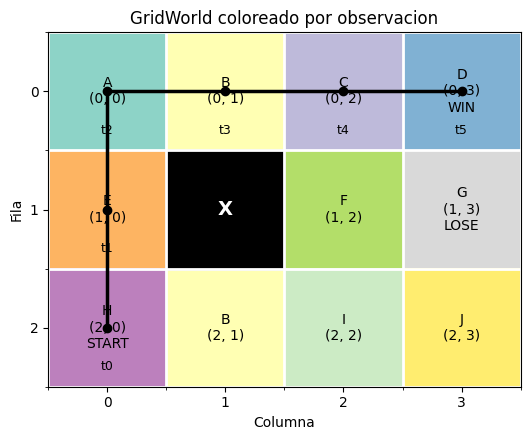

Clases de observacion:
A -> U:1 D:0 L:1 R:0 -> [(0, 0)]
B -> U:1 D:1 L:0 R:0 -> [(0, 1), (2, 1)]
C -> U:1 D:0 L:0 R:0 -> [(0, 2)]
D -> U:1 D:0 L:0 R:1 -> [(0, 3)]
E -> U:0 D:0 L:1 R:1 -> [(1, 0)]
F -> U:0 D:0 L:1 R:0 -> [(1, 2)]
G -> U:0 D:0 L:0 R:1 -> [(1, 3)]
H -> U:0 D:1 L:1 R:0 -> [(2, 0)]
I -> U:0 D:1 L:0 R:0 -> [(2, 2)]
J -> U:0 D:1 L:0 R:1 -> [(2, 3)]


In [21]:
plot_sensor_alias_grid(actions=["up", "up", "right", "right", "right"])

### Ejemplo 4: Memoria Mínima

### Helpers

In [22]:
def rolling_mean(x, window=100):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def epsilon_greedy(q_table, state, actions, epsilon, rng):
    if rng.random() < epsilon:
        return str(rng.choice(actions))

    q_values = np.array([q_table[state][a] for a in actions], dtype=float)
    best_idx = np.flatnonzero(q_values == q_values.max())
    return actions[int(rng.choice(best_idx))]


def greedy_action(q_table, state, actions):
    q_values = np.array([q_table[state][a] for a in actions], dtype=float)
    return actions[int(np.argmax(q_values))]

Sin memoria el agente falla; con una memoria de 1 paso mejora.

In [23]:
@dataclass
class CueCorridorPOMDP:
    seed: int = 0
    rng: np.random.Generator = field(init=False, repr=False)
    goal_side: str = field(init=False)
    phase: str = field(init=False)
    done: bool = field(init=False)

    def __post_init__(self):
        self.rng = np.random.default_rng(self.seed)
        self.reset()

    def reset(self, goal_side=None):
        if goal_side is None:
            goal_side = str(self.rng.choice(["left", "right"]))
        self.goal_side = goal_side
        self.phase = "cue"
        self.done = False
        return self.observe()

    def observe(self):
        if self.phase == "cue":
            return f"cue_{self.goal_side}"
        if self.phase == "junction":
            return "junction"
        return "terminal"

    def valid_actions(self):
        if self.phase == "cue":
            return ["advance"]
        if self.phase == "junction":
            return ["left", "right"]
        return []

    def step(self, action):
        if self.done:
            raise ValueError("El episodio ya terminó.")

        if self.phase == "cue":
            if action != "advance":
                raise ValueError("En la fase cue la única acción válida es 'advance'.")
            self.phase = "junction"
            return self.observe(), 0.0, False

        if self.phase == "junction":
            if action not in {"left", "right"}:
                raise ValueError(
                    "En la junction las acciones válidas son 'left' y 'right'."
                )
            reward = 1.0 if action == self.goal_side else -1.0
            self.phase = "terminal"
            self.done = True
            return self.observe(), reward, True

        raise ValueError("Fase inválida")

In [24]:
def encode_state(observation, prev_observation, mode="obs_only"):
    if mode == "obs_only":
        return observation
    if mode == "memory_1":
        prev_token = "none" if prev_observation is None else prev_observation
        return (prev_token, observation)
    raise ValueError(f"Modo desconocido: {mode}")


def make_q_table():
    return defaultdict(lambda: {"advance": 0.0, "left": 0.0, "right": 0.0})

In [25]:
def train_q_agent(
    episodes=4000,
    mode="obs_only",
    alpha=0.15,
    gamma=0.95,
    epsilon_start=0.25,
    epsilon_min=0.02,
    epsilon_decay=0.999,
    seed=0,
):
    env = CueCorridorPOMDP(seed=seed)
    rng = np.random.default_rng(seed)
    q_table = make_q_table()

    episode_returns = []
    success_flags = []

    epsilon = epsilon_start

    for _ in range(episodes):
        observation = env.reset()
        prev_observation = None
        done = False
        total_reward = 0.0

        while not done:
            state = encode_state(observation, prev_observation, mode)
            actions = env.valid_actions()

            action = epsilon_greedy(q_table, state, actions, epsilon, rng)
            next_observation, reward, done = env.step(action)

            next_prev_observation = observation
            total_reward += reward

            if done:
                td_target = reward
            else:
                next_state = encode_state(next_observation, next_prev_observation, mode)
                next_actions = env.valid_actions()
                td_target = reward + gamma * max(
                    q_table[next_state][a] for a in next_actions
                )

            q_table[state][action] += alpha * (td_target - q_table[state][action])

            prev_observation = next_prev_observation
            observation = next_observation

        episode_returns.append(total_reward)
        success_flags.append(total_reward > 0)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return q_table, np.array(episode_returns), np.array(success_flags)


def evaluate_agent(q_table, mode="obs_only", episodes=500, seed=123):
    rng = np.random.default_rng(seed)
    returns = []

    for _ in range(episodes):
        goal_side = str(rng.choice(["left", "right"]))
        env = CueCorridorPOMDP(seed=seed)

        observation = env.reset(goal_side=goal_side)
        prev_observation = None
        done = False
        total_reward = 0.0

        while not done:
            state = encode_state(observation, prev_observation, mode)
            actions = env.valid_actions()
            action = greedy_action(q_table, state, actions)

            next_observation, reward, done = env.step(action)
            total_reward += reward

            prev_observation = observation
            observation = next_observation

        returns.append(total_reward)

    returns = np.array(returns)
    success_rate = (returns > 0).mean()
    return returns, success_rate


def run_trace(q_table, mode="obs_only", goal_side="left"):
    env = CueCorridorPOMDP(seed=999)
    observation = env.reset(goal_side=goal_side)
    prev_observation = None
    done = False
    trace = []

    while not done:
        state = encode_state(observation, prev_observation, mode)
        actions = env.valid_actions()
        action = greedy_action(q_table, state, actions)
        next_observation, reward, done = env.step(action)

        trace.append(
            {
                "prev_obs": prev_observation,
                "obs": observation,
                "state_repr": state,
                "action": action,
                "reward": reward,
                "done": done,
            }
        )

        prev_observation = observation
        observation = next_observation

    return trace

In [26]:
q_obs, returns_obs, success_obs = train_q_agent(mode="obs_only", episodes=4000, seed=1)
q_mem, returns_mem, success_mem = train_q_agent(mode="memory_1", episodes=4000, seed=1)

eval_returns_obs, eval_sr_obs = evaluate_agent(
    q_obs, mode="obs_only", episodes=800, seed=7
)
eval_returns_mem, eval_sr_mem = evaluate_agent(
    q_mem, mode="memory_1", episodes=800, seed=7
)

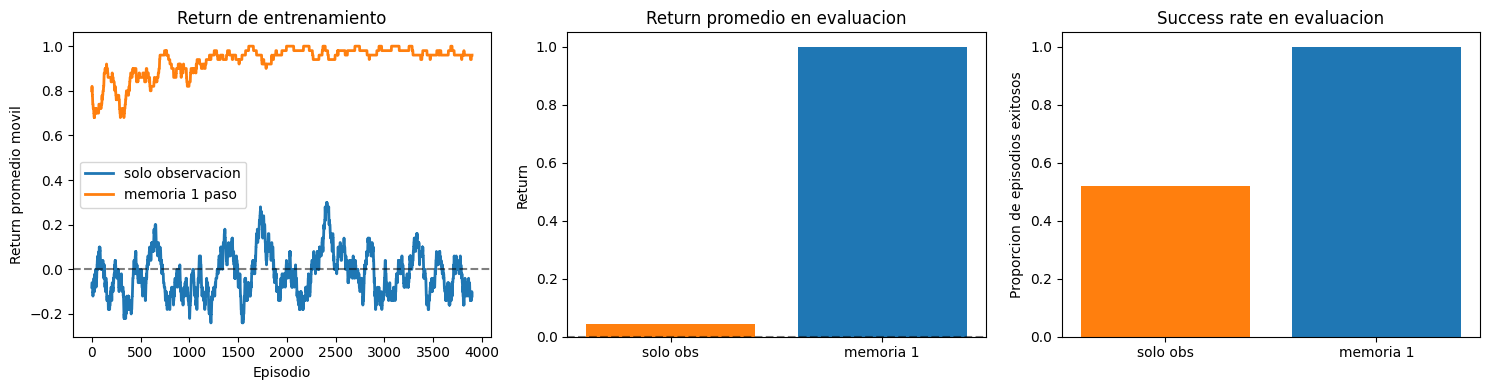

Evaluacion final
solo observacion -> return medio = 0.043 | success rate = 0.521
memoria 1 paso  -> return medio = 1.000 | success rate = 1.000


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rolling_mean(returns_obs, 100), label="solo observacion", linewidth=2)
axes[0].plot(rolling_mean(returns_mem, 100), label="memoria 1 paso", linewidth=2)
axes[0].axhline(0.0, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("Return de entrenamiento")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Return promedio movil")
axes[0].legend()

axes[1].bar(
    ["solo obs", "memoria 1"],
    [eval_returns_obs.mean(), eval_returns_mem.mean()],
    color=["tab:orange", "tab:blue"],
)
axes[1].axhline(0.0, color="black", linestyle="--", alpha=0.5)
axes[1].set_title("Return promedio en evaluacion")
axes[1].set_ylabel("Return")

axes[2].bar(
    ["solo obs", "memoria 1"],
    [eval_sr_obs, eval_sr_mem],
    color=["tab:orange", "tab:blue"],
)
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Success rate en evaluacion")
axes[2].set_ylabel("Proporcion de episodios exitosos")

plt.tight_layout()
plt.show()

print("Evaluacion final")
print(
    f"solo observacion -> return medio = {eval_returns_obs.mean():.3f} | success rate = {eval_sr_obs:.3f}"
)
print(
    f"memoria 1 paso  -> return medio = {eval_returns_mem.mean():.3f} | success rate = {eval_sr_mem:.3f}"
)

In [28]:
print("Q-values del agente sin memoria en la junction:")
print({a: round(q_obs["junction"][a], 3) for a in ["left", "right"]})

print("\nQ-values del agente con memoria en la junction:")
print("si antes vio cue_left:")
print({a: round(q_mem[("cue_left", "junction")][a], 3) for a in ["left", "right"]})
print("si antes vio cue_right:")
print({a: round(q_mem[("cue_right", "junction")][a], 3) for a in ["left", "right"]})

Q-values del agente sin memoria en la junction:
{'left': -0.738, 'right': -0.424}

Q-values del agente con memoria en la junction:
si antes vio cue_left:
{'left': 1.0, 'right': -1.0}
si antes vio cue_right:
{'left': -1.0, 'right': 1.0}


### Ejemplo 5: Q-learning y representación del estado

Cambia la representación del estado. El algoritmo, no.

In [29]:
@dataclass
class NoisyCueSequencePOMDP:
    n_cues: int = 7
    cue_accuracy: float = 0.70
    seed: int = 0
    rng: np.random.Generator = field(init=False, repr=False)
    goal_side: str = field(init=False)
    t: int = field(init=False)
    done: bool = field(init=False)
    cues: list = field(init=False)

    def __post_init__(self):
        self.rng = np.random.default_rng(self.seed)
        self.reset()

    def reset(self, goal_side=None):
        if goal_side is None:
            goal_side = str(self.rng.choice(["left", "right"]))
        self.goal_side = goal_side
        self.t = 0
        self.done = False

        correct_obs = f"cue_{self.goal_side}"
        wrong_obs = "cue_right" if self.goal_side == "left" else "cue_left"

        self.cues = [
            correct_obs if self.rng.random() < self.cue_accuracy else wrong_obs
            for _ in range(self.n_cues)
        ]
        return self.observe()

    def observe(self):
        if self.done:
            return "terminal"
        if self.t < self.n_cues:
            return self.cues[self.t]
        return "junction"

    def valid_actions(self):
        if self.done:
            return []
        if self.t < self.n_cues:
            return ["advance"]
        return ["left", "right"]

    def step(self, action):
        if self.done:
            raise ValueError("El episodio ya termino.")

        if self.t < self.n_cues:
            if action != "advance":
                raise ValueError(
                    "Antes de la junction la unica accion valida es 'advance'."
                )
            self.t += 1
            return self.observe(), 0.0, False

        if action not in {"left", "right"}:
            raise ValueError(
                "En la junction las acciones validas son 'left' y 'right'."
            )

        reward = 1.0 if action == self.goal_side else -1.0
        self.done = True
        return self.observe(), reward, True


def bayes_update_goal_left(pr_left, observation, cue_accuracy):
    if observation not in {"cue_left", "cue_right"}:
        return pr_left

    if observation == "cue_left":
        likelihood_if_left = cue_accuracy
        likelihood_if_right = 1.0 - cue_accuracy
    else:
        likelihood_if_left = 1.0 - cue_accuracy
        likelihood_if_right = cue_accuracy

    numerator = likelihood_if_left * pr_left
    denominator = numerator + likelihood_if_right * (1.0 - pr_left)
    return numerator / denominator


def maybe_update_belief(pr_left, observation, cue_accuracy):
    if observation in {"cue_left", "cue_right"}:
        return bayes_update_goal_left(pr_left, observation, cue_accuracy)
    return pr_left

In [30]:
BELIEF_BINS = 15

In [31]:
def belief_to_bin(pr_left, n_bins=BELIEF_BINS):
    idx = int(np.round(pr_left * (n_bins - 1)))
    return int(np.clip(idx, 0, n_bins - 1))


def encode_agent_state(obs, prev_obs, belief_left, mode="obs_only", n_bins=BELIEF_BINS):
    if mode == "obs_only":
        return obs

    if mode == "memory_1":
        return (prev_obs if prev_obs is not None else "none", obs)

    if mode == "belief":
        return (obs, belief_to_bin(belief_left, n_bins))

    raise ValueError(f"Modo desconocido: {mode}")

In [32]:
def train_q_agent_on_representation(
    mode="obs_only",
    episodes=6000,
    n_cues=7,
    cue_accuracy=0.70,
    alpha=0.10,
    gamma=1.00,
    epsilon_start=0.30,
    epsilon_min=0.02,
    epsilon_decay=0.999,
    belief_bins=BELIEF_BINS,
    seed=0,
):
    rng = np.random.default_rng(seed)
    q_table = defaultdict(lambda: defaultdict(float))

    returns = []
    success = []

    epsilon = epsilon_start

    for _ in range(episodes):
        env_seed = int(rng.integers(0, 1_000_000_000))
        env = NoisyCueSequencePOMDP(
            n_cues=n_cues,
            cue_accuracy=cue_accuracy,
            seed=env_seed,
        )

        obs = env.reset()
        prev_obs = None
        belief_left = maybe_update_belief(0.5, obs, cue_accuracy)

        done = False
        total_reward = 0.0

        while not done:
            state = encode_agent_state(
                obs=obs,
                prev_obs=prev_obs,
                belief_left=belief_left,
                mode=mode,
                n_bins=belief_bins,
            )

            actions = env.valid_actions()
            action = epsilon_greedy(q_table, state, actions, epsilon, rng)

            next_obs, reward, done = env.step(action)
            total_reward += reward

            next_prev_obs = obs
            next_belief_left = maybe_update_belief(belief_left, next_obs, cue_accuracy)

            if done:
                td_target = reward
            else:
                next_state = encode_agent_state(
                    obs=next_obs,
                    prev_obs=next_prev_obs,
                    belief_left=next_belief_left,
                    mode=mode,
                    n_bins=belief_bins,
                )
                next_actions = env.valid_actions()
                td_target = reward + gamma * max(
                    q_table[next_state][a] for a in next_actions
                )

            q_table[state][action] += alpha * (td_target - q_table[state][action])

            prev_obs = next_prev_obs
            obs = next_obs
            belief_left = next_belief_left

        returns.append(total_reward)
        success.append(float(total_reward > 0))
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return q_table, np.asarray(returns), np.asarray(success)


def evaluate_q_agent(
    q_table,
    mode="obs_only",
    episodes=3000,
    n_cues=7,
    cue_accuracy=0.70,
    belief_bins=BELIEF_BINS,
    seed=123,
):
    rng = np.random.default_rng(seed)
    rewards = []

    for _ in range(episodes):
        env_seed = int(rng.integers(0, 1_000_000_000))
        goal_side = str(rng.choice(["left", "right"]))

        env = NoisyCueSequencePOMDP(
            n_cues=n_cues,
            cue_accuracy=cue_accuracy,
            seed=env_seed,
        )

        obs = env.reset(goal_side=goal_side)
        prev_obs = None
        belief_left = maybe_update_belief(0.5, obs, cue_accuracy)

        done = False
        total_reward = 0.0

        while not done:
            state = encode_agent_state(
                obs=obs,
                prev_obs=prev_obs,
                belief_left=belief_left,
                mode=mode,
                n_bins=belief_bins,
            )
            actions = env.valid_actions()
            action = greedy_action(q_table, state, actions)

            next_obs, reward, done = env.step(action)
            total_reward += reward

            prev_obs = obs
            obs = next_obs
            belief_left = maybe_update_belief(belief_left, obs, cue_accuracy)

        rewards.append(total_reward)

    rewards = np.asarray(rewards, dtype=float)
    return {
        "mean_reward": rewards.mean(),
        "success_rate": (rewards > 0).mean(),
        "rewards": rewards,
    }

In [33]:
N_CUES = 7
CUE_ACCURACY = 0.70
TRAIN_EPISODES = 6000
EVAL_EPISODES = 4000
trained = {}

In [34]:
for mode in ["obs_only", "memory_1", "belief"]:
    q_table, train_returns, train_success = train_q_agent_on_representation(
        mode=mode,
        episodes=TRAIN_EPISODES,
        n_cues=N_CUES,
        cue_accuracy=CUE_ACCURACY,
        seed=7,
    )
    eval_stats = evaluate_q_agent(
        q_table,
        mode=mode,
        episodes=EVAL_EPISODES,
        n_cues=N_CUES,
        cue_accuracy=CUE_ACCURACY,
        seed=99,
    )
    trained[mode] = {
        "q": q_table,
        "train_returns": train_returns,
        "train_success": train_success,
        "eval": eval_stats,
    }

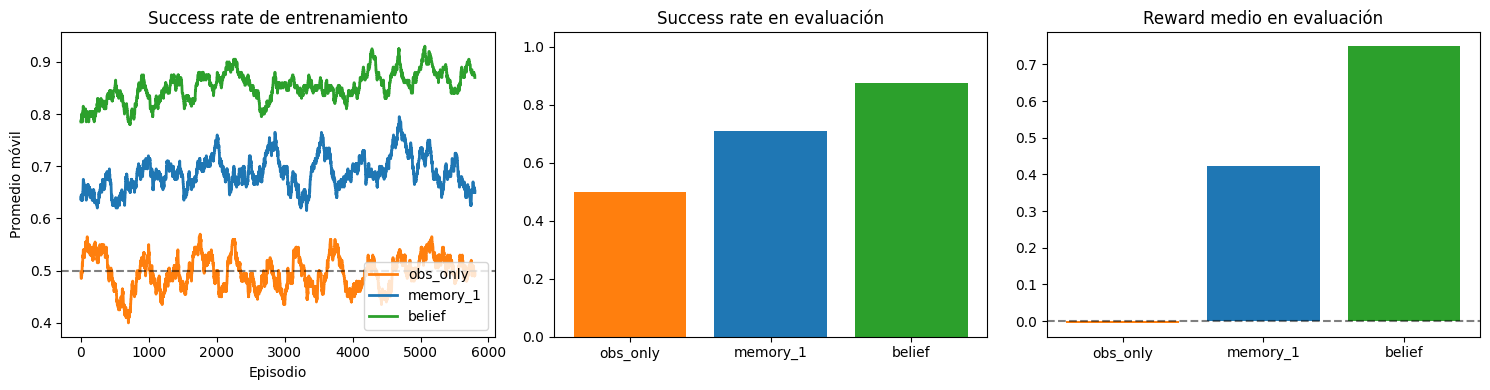

  obs_only -> success_rate=0.497 | mean_reward=-0.005
  memory_1 -> success_rate=0.711 | mean_reward=0.422
    belief -> success_rate=0.875 | mean_reward=0.750


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for mode, color in zip(
    ["obs_only", "memory_1", "belief"],
    ["tab:orange", "tab:blue", "tab:green"],
):
    axes[0].plot(
        rolling_mean(trained[mode]["train_success"], 200),
        label=mode,
        linewidth=2,
        color=color,
    )

axes[0].axhline(0.5, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("Success rate de entrenamiento")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Promedio móvil")
axes[0].legend()

modes = ["obs_only", "memory_1", "belief"]
success_rates = [trained[m]["eval"]["success_rate"] for m in modes]
mean_rewards = [trained[m]["eval"]["mean_reward"] for m in modes]

axes[1].bar(modes, success_rates, color=["tab:orange", "tab:blue", "tab:green"])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Success rate en evaluación")

axes[2].bar(modes, mean_rewards, color=["tab:orange", "tab:blue", "tab:green"])
axes[2].axhline(0.0, color="black", linestyle="--", alpha=0.5)
axes[2].set_title("Reward medio en evaluación")

plt.tight_layout()
plt.show()

for mode in modes:
    print(
        f"{mode:>10} -> "
        f"success_rate={trained[mode]['eval']['success_rate']:.3f} | "
        f"mean_reward={trained[mode]['eval']['mean_reward']:.3f}"
    )

In [36]:
q_obs = trained["obs_only"]["q"]
q_mem = trained["memory_1"]["q"]
q_bel = trained["belief"]["q"]

Q-values en junction para obs_only:
{'left': 0.252, 'right': -0.374}

Q-values en junction para memory_1:
si la última cue fue left:
{'left': 0.393, 'right': -0.225}
si la última cue fue right:
{'left': -0.414, 'right': 0.023}


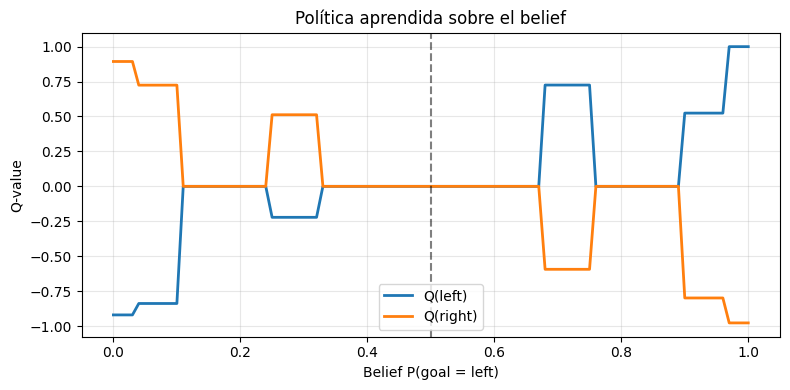

In [37]:
print("Q-values en junction para obs_only:")
print({a: round(q_obs["junction"][a], 3) for a in ["left", "right"]})

print("\nQ-values en junction para memory_1:")
print("si la última cue fue left:")
print({a: round(q_mem[("cue_left", "junction")][a], 3) for a in ["left", "right"]})
print("si la última cue fue right:")
print({a: round(q_mem[("cue_right", "junction")][a], 3) for a in ["left", "right"]})

belief_grid = np.linspace(0.0, 1.0, 101)
left_q = []
right_q = []

for p in belief_grid:
    s = ("junction", belief_to_bin(p, BELIEF_BINS))
    left_q.append(q_bel[s]["left"])
    right_q.append(q_bel[s]["right"])

plt.figure(figsize=(8, 4))
plt.plot(belief_grid, left_q, label="Q(left)", linewidth=2)
plt.plot(belief_grid, right_q, label="Q(right)", linewidth=2)
plt.axvline(0.5, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Belief P(goal = left)")
plt.ylabel("Q-value")
plt.title("Política aprendida sobre el belief")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Bonus: storyboard, animaciones y rango de cue

In [38]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

In [39]:
try:
    q_obs
    q_mem
except NameError:
    q_obs, _, _ = train_q_agent(mode="obs_only", episodes=4000, seed=1)
    q_mem, _, _ = train_q_agent(mode="memory_1", episodes=4000, seed=1)

In [40]:
def collect_story_frames(q_table, mode="obs_only", goal_side="left"):
    env = CueCorridorPOMDP(seed=999)
    observation = env.reset(goal_side=goal_side)
    prev_observation = None

    frames = []

    state = encode_state(observation, prev_observation, mode)
    frames.append(
        {
            "phase": "cue",
            "agent_pos": "cue",
            "observation": observation,
            "prev_observation": prev_observation,
            "state_repr": state,
            "q_values": {a: q_table[state][a] for a in env.valid_actions()},
            "action": None,
            "goal_side": env.goal_side,
            "reward": 0.0,
            "caption": "El agente observa la pista inicial",
        }
    )

    action_1 = greedy_action(q_table, state, env.valid_actions())
    next_observation, _, _ = env.step(action_1)

    frames.append(
        {
            "phase": "junction",
            "agent_pos": "junction",
            "observation": next_observation,
            "prev_observation": observation,
            "state_repr": encode_state(next_observation, observation, mode),
            "q_values": None,
            "action": "advance",
            "goal_side": env.goal_side,
            "reward": 0.0,
            "caption": "Avanza desde la pista hasta la bifurcación",
        }
    )

    prev_observation = observation
    observation = next_observation
    state = encode_state(observation, prev_observation, mode)
    action_2 = greedy_action(q_table, state, env.valid_actions())

    frames.append(
        {
            "phase": "junction",
            "agent_pos": "junction",
            "observation": observation,
            "prev_observation": prev_observation,
            "state_repr": state,
            "q_values": {a: q_table[state][a] for a in env.valid_actions()},
            "action": action_2,
            "goal_side": env.goal_side,
            "reward": 0.0,
            "caption": "Decide izquierda o derecha en la junction",
        }
    )

    next_observation, reward, _ = env.step(action_2)

    frames.append(
        {
            "phase": "terminal",
            "agent_pos": action_2,
            "observation": next_observation,
            "prev_observation": observation,
            "state_repr": "terminal",
            "q_values": None,
            "action": action_2,
            "goal_side": env.goal_side,
            "reward": reward,
            "caption": f"Resultado final: reward = {reward:+.0f}",
        }
    )

    return frames


def _format_q_values(q_values):
    if q_values is None:
        return "-"
    return " | ".join(f"{a}: {v:.2f}" for a, v in q_values.items())


def draw_episode_frame(ax, frame, title=""):
    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)
    ax.axis("off")

    goal_side = frame["goal_side"]

    safe_color = "#b9f6ca"
    danger_color = "#ffccbc"
    neutral_color = "#eceff1"
    cue_color = "#fff3cd"
    agent_color = "#1976d2"

    left_door_color = safe_color if goal_side == "left" else danger_color
    right_door_color = safe_color if goal_side == "right" else danger_color

    cue_box = Rectangle(
        (0.8, 1.7), 1.8, 1.6, facecolor=cue_color, edgecolor="black", linewidth=1.5
    )
    left_door = Rectangle(
        (8.0, 3.0),
        1.4,
        1.0,
        facecolor=left_door_color,
        edgecolor="black",
        linewidth=1.5,
    )
    right_door = Rectangle(
        (8.0, 1.0),
        1.4,
        1.0,
        facecolor=right_door_color,
        edgecolor="black",
        linewidth=1.5,
    )

    ax.add_patch(cue_box)
    ax.add_patch(left_door)
    ax.add_patch(right_door)

    junction = Circle(
        (5.0, 2.5), 0.38, facecolor=neutral_color, edgecolor="black", linewidth=1.5
    )
    ax.add_patch(junction)

    ax.add_patch(
        FancyArrowPatch(
            (2.6, 2.5),
            (4.45, 2.5),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=2,
            color="gray",
        )
    )
    ax.add_patch(
        FancyArrowPatch(
            (5.35, 2.75),
            (7.85, 3.45),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=2,
            color="gray",
        )
    )
    ax.add_patch(
        FancyArrowPatch(
            (5.35, 2.25),
            (7.85, 1.55),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=2,
            color="gray",
        )
    )

    ax.text(1.7, 3.55, "CUE", ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(
        5.0, 3.15, "JUNCTION", ha="center", va="center", fontsize=10, fontweight="bold"
    )
    ax.text(8.7, 4.2, "LEFT", ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(8.7, 2.2, "RIGHT", ha="center", va="center", fontsize=10, fontweight="bold")

    ax.text(
        8.7,
        3.45,
        "SAFE" if goal_side == "left" else "BAD",
        ha="center",
        va="center",
        fontsize=10,
    )
    ax.text(
        8.7,
        1.45,
        "SAFE" if goal_side == "right" else "BAD",
        ha="center",
        va="center",
        fontsize=10,
    )

    obs = frame["observation"]
    if obs.startswith("cue_"):
        cue_label = obs.replace("cue_", "").upper()
        ax.text(
            1.7, 2.45, cue_label, ha="center", va="center", fontsize=12, color="#6d4c41"
        )
    else:
        ax.text(
            1.7, 2.45, "...", ha="center", va="center", fontsize=12, color="#6d4c41"
        )

    positions = {
        "cue": (1.7, 2.15),
        "junction": (5.0, 2.5),
        "left": (8.7, 3.45),
        "right": (8.7, 1.45),
    }
    agent_x, agent_y = positions[frame["agent_pos"]]
    agent = Circle(
        (agent_x, agent_y),
        0.18,
        facecolor=agent_color,
        edgecolor="white",
        linewidth=1.5,
    )
    ax.add_patch(agent)

    if frame["action"] == "advance":
        ax.text(
            3.5, 2.82, "advance", ha="center", va="center", fontsize=10, color="#37474f"
        )
    elif frame["action"] == "left":
        ax.text(
            6.8,
            3.15,
            "choose LEFT",
            ha="center",
            va="center",
            fontsize=10,
            color="#37474f",
        )
        left_door.set_linewidth(3)
    elif frame["action"] == "right":
        ax.text(
            6.8,
            1.85,
            "choose RIGHT",
            ha="center",
            va="center",
            fontsize=10,
            color="#37474f",
        )
        right_door.set_linewidth(3)

    info_lines = [
        f"observacion: {frame['observation']}",
        f"prev_obs: {frame['prev_observation']}",
        f"estado para la politica: {frame['state_repr']}",
        f"Q-values: {_format_q_values(frame['q_values'])}",
        frame["caption"],
    ]

    y0 = 4.65
    for i, line in enumerate(info_lines):
        ax.text(0.2, y0 - 0.28 * i, line, fontsize=9.5, ha="left", va="top")

    ax.set_title(title, fontsize=12, pad=10)


def compare_storyboards(goal_side="left"):
    frames_obs = collect_story_frames(q_obs, mode="obs_only", goal_side=goal_side)
    frames_mem = collect_story_frames(q_mem, mode="memory_1", goal_side=goal_side)

    n = len(frames_obs)
    fig, axes = plt.subplots(2, n, figsize=(4.6 * n, 8))

    for i in range(n):
        draw_episode_frame(axes[0, i], frames_obs[i], title=f"Solo observacion | t={i}")
        draw_episode_frame(axes[1, i], frames_mem[i], title=f"Memoria 1 paso | t={i}")

    plt.suptitle(
        f"Comparacion visual del episodio | goal_side = {goal_side}",
        fontsize=15,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


def animate_comparison(goal_side="left", interval=1400):
    frames_obs = collect_story_frames(q_obs, mode="obs_only", goal_side=goal_side)
    frames_mem = collect_story_frames(q_mem, mode="memory_1", goal_side=goal_side)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    def update(frame_idx):
        draw_episode_frame(
            axes[0], frames_obs[frame_idx], title=f"Solo observacion | t={frame_idx}"
        )
        draw_episode_frame(
            axes[1], frames_mem[frame_idx], title=f"Memoria 1 paso | t={frame_idx}"
        )

    anim = FuncAnimation(
        fig, update, frames=len(frames_obs), interval=interval, repeat=True
    )
    plt.close(fig)
    return anim

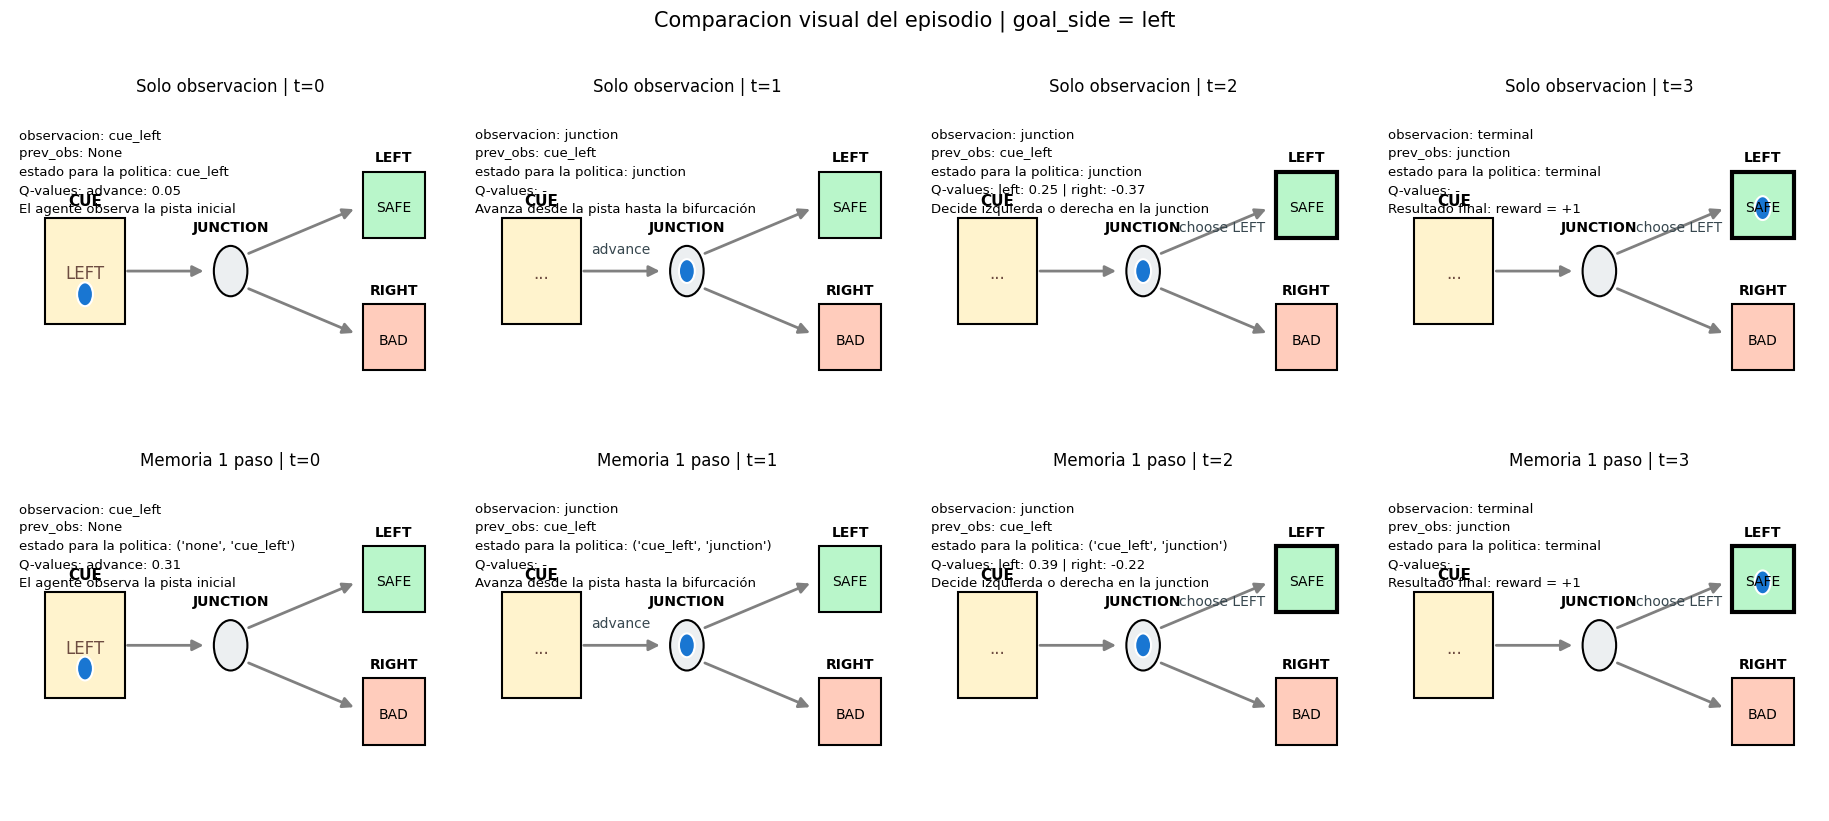

In [41]:
compare_storyboards(goal_side="left")

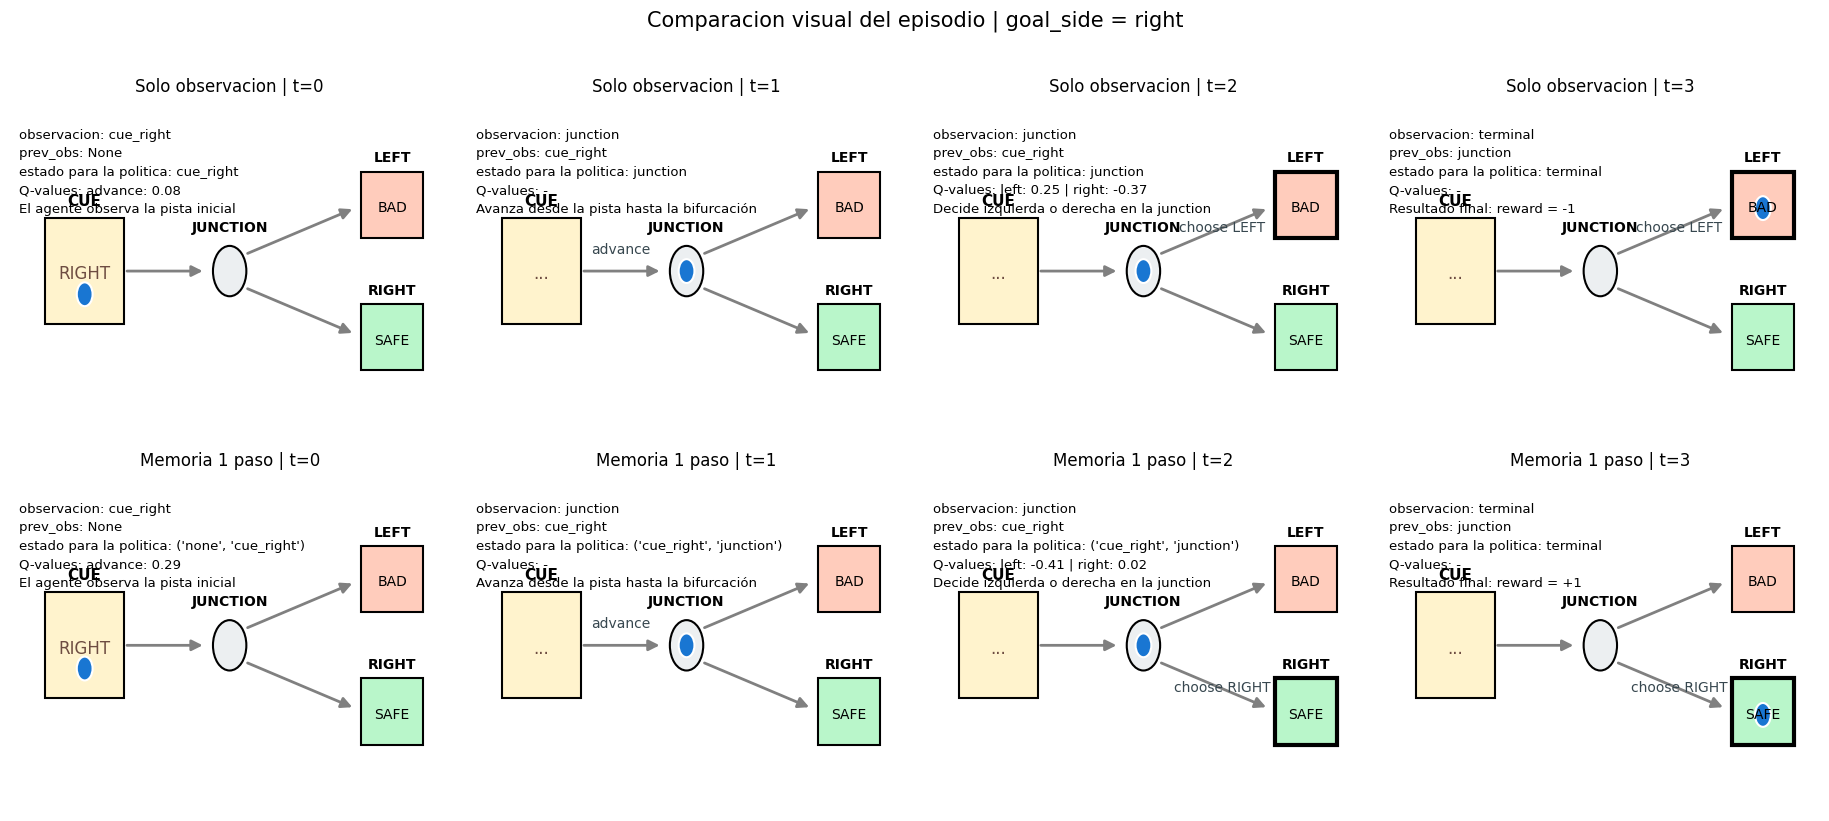

In [42]:
compare_storyboards(goal_side="right")

In [43]:
HTML(animate_comparison(goal_side="left", interval=1500).to_jshtml())

In [44]:
HTML(animate_comparison(goal_side="right", interval=1500).to_jshtml())

In [45]:
cue_range = range(1, 10)
sweep = {
    "obs_only": [],
    "memory_1": [],
    "belief": [],
}

In [46]:
for n_cues in cue_range:
    for mode in sweep:
        q_table, _, _ = train_q_agent_on_representation(
            mode=mode,
            episodes=3500,
            n_cues=n_cues,
            cue_accuracy=0.70,
            seed=10 + n_cues,
        )
        stats = evaluate_q_agent(
            q_table,
            mode=mode,
            episodes=2500,
            n_cues=n_cues,
            cue_accuracy=0.70,
            seed=200 + n_cues,
        )
        sweep[mode].append(stats["success_rate"])

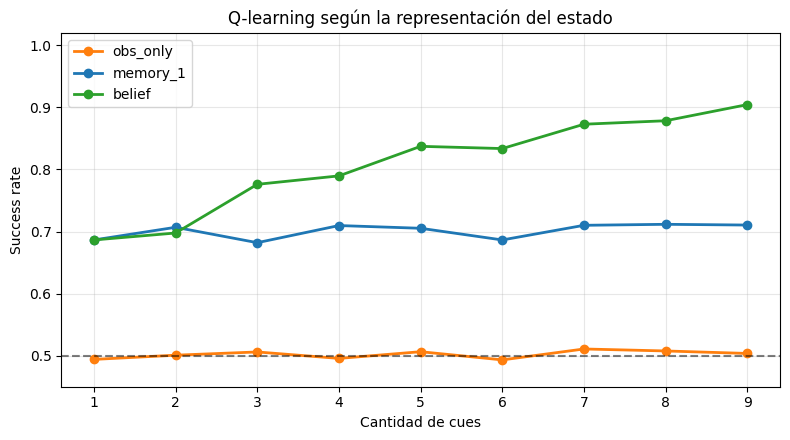

In [47]:
plt.figure(figsize=(8, 4.5))
for mode, color in zip(
    ["obs_only", "memory_1", "belief"],
    ["tab:orange", "tab:blue", "tab:green"],
):
    plt.plot(
        list(cue_range),
        sweep[mode],
        marker="o",
        linewidth=2,
        label=mode,
        color=color,
    )

plt.axhline(0.5, color="black", linestyle="--", alpha=0.5)
plt.ylim(0.45, 1.02)
plt.xlabel("Cantidad de cues")
plt.ylabel("Success rate")
plt.title("Q-learning según la representación del estado")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Ejercicios

1. ¿Qué expresa la propiedad de Markov y por qué es importante en aprendizaje por refuerzo?
2. ¿Cuál es la diferencia entre un MDP y un POMDP?
3. ¿Por qué en un POMDP la observación actual o_t puede no ser suficiente para decidir bien?
4. ¿Qué representa el belief state y por qué se interpreta como una distribución bayesiana?
5. Explicá con tus palabras la actualización: $belief nuevo ∝ likelihood × belief predicho$
6. En el ejemplo del corredor, ¿por qué la observación hallway no identifica un único estado?
7. En Tiger, ¿cuándo conviene escuchar y cuándo conviene abrir una puerta?
8. En el GridWorld con sensores, ¿por qué dos estados distintos pueden generar la misma observación?
9. ¿Qué gana el agente cuando pasa de $obs_only$ a $memory_1$?
10. En el experimento final, ¿por qué Q-learning mejora al cambiar la representación del estado aunque el algoritmo sea el mismo?
11. ¿Qué relación hay entre belief state, frame stacking y redes recurrentes como LSTM?
12. ¿Por qué un problema parcialmente observable puede requerir memoria aunque el entorno subyacente sea markoviano?

### Preguntas de análisis

13. Si el sensor fuera perfecto, ¿seguiría siendo un POMDP?
14. Si aumentamos el ruido de las observaciones, ¿qué esperás que pase con el rendimiento de obs_only, memory_1 y belief?
15. ¿Qué limitaciones tiene usar solo memoria de un paso?
16. ¿Qué ventaja tiene discretizar el belief para usar Q-learning?
17. ¿Qué problemas aparecen si el espacio de belief es continuo?

### Preguntas: Ejercicios

18. Modificá el corredor para que haya observaciones ruidosas y analizá cómo cambia el belief.
19. Cambiá la precisión del sensor en Tiger y graficá cómo cambia la política óptima.
20. En el GridWorld, agregá ruido a los sensores y compará con la versión determinista.
Compará tres agentes: $obs_only$, $memory_1$ y $belief$, manteniendo fijo el mismo entorno y la misma recompensa.
21. Relacioná los resultados obtenidos con la necesidad de usar recurrent PPO en problemas más complejos.


## Referencias

* Richard S. Sutton, Andrew G. Barto. Reinforcement Learning: An Introduction. 2nd ed., 2018.
* Martin L. Puterman. Markov Decision Processes: Discrete Stochastic Dynamic Programming. 1994.
* Leslie Pack Kaelbling, Michael L. Littman, Anthony R. Cassandra. Planning and Acting in Partially Observable Stochastic Domains. Artificial Intelligence, 1998.
* Stuart Russell, Peter Norvig. Artificial Intelligence: A Modern Approach. 4th ed.
* Anthony R. Cassandra. A Survey of POMDP Applications. 1998.
* Karl J. Astrom. Optimal Control of Markov Processes with Incomplete State Estimation. 1965.